In [1]:
# connect colab to drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Install Required Libraries

In [3]:
!pip install pymatgen torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.4 MB/s eta 0:00:00
  Created

## Get the data

In [4]:
import pandas as pd
import numpy as np

BASE_DIR = '/content/drive/MyDrive/Project'
DATA_PATH = f"{BASE_DIR}/Dataset.csv"

data_df = pd.read_csv(DATA_PATH)
data_df.head()

,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-331,ScAl,Pm3m,221,2.0,0.0000,3.370349,3.370349,3.370349,90.000000,90.000000,90.000000,1.0,1.485,TI,1,cif_files/mp-331.cif
1,mp-698479,RbTeHOF4,Cc,9,32.0,4.8825,8.430517,8.430517,14.075609,85.886490,85.886490,34.382176,6.4,3.060,Trivial,0,cif_files/mp-698479.cif
2,mp-549237,Sr2Fe2S2OF2,I4/mmm,139,18.0,1.4677,4.095118,4.096245,18.221803,90.002343,90.003680,89.993481,3.6,2.458,Trivial,0,cif_files/mp-549237.cif
3,mp-13089,Cu2SnTe3,Imm2,44,6.0,0.0000,4.409910,6.113668,7.554224,113.869340,106.970766,90.000000,1.0,2.010,Trivial,0,cif_files/mp-13089.cif
4,mp-10732,ThTaN3,Pm-3m,221,5.0,0.0766,4.064437,4.064437,4.064437,90.000000,90.000000,90.000000,1.0,2.384,Topological,1,cif_files/mp-10732.cif


In [5]:
# Is the data distributed in a balanced manner?
print("\nLabel distribution:\n")
data_df['label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'


Label distribution:



,proportion
label,
0,50.5%
1,49.5%


## Split the Data

In [6]:
# Stratified train/validation/test split (70/15/15)
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
train_df, temp_df = train_test_split(
    data_df, test_size=0.30, random_state=42, stratify=data_df['label']
)

# Second split: 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
)

## Create Graphical Representation of the Structure

In [27]:
# Get sample structure
from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

struct_0 = data_df.iloc[0]['cif']
sample_structure = Structure.from_file(f"{BASE_DIR}/{struct_0}")
sample_label = data_df.iloc[0]['label']
sample_band_gap = data_df.iloc[0]['Band Gap']
sample_structure

Structure Summary
Lattice
    abc : 3.37034897 3.37034897 3.37034897
 angles : 90.0 90.0 90.0
 volume : 38.28464388341792
      A : np.float64(3.37034897) np.float64(0.0) np.float64(2.0637435390600394e-16)
      B : np.float64(5.419934515971323e-16) np.float64(3.37034897) np.float64(2.0637435390600394e-16)
      C : np.float64(0.0) np.float64(0.0) np.float64(3.37034897)
    pbc : True True True
PeriodicSite: Sc0 (Sc) (1.685, 1.685, 1.685) [0.5, 0.5, 0.5]
PeriodicSite: Al1 (Al) (0.0, 0.0, 0.0) [0.0, 0.0, 0.0]

In [8]:
import torch
import torch.nn as nn
from torch_geometric.data import Data, DataLoader

In [28]:
def get_graph_rep(structure, label, band_gap):

    # -----------------------
    # Node features
    # -----------------------
    nodes = []

    for site in structure:
        node_features = [
            site.specie.Z,                                                                   # Atomic number of the atom
            site.specie.X if site.specie.X is not None else 0.0,                             # Electronegativity of the atom; set to 0.0 if missing
            float(site.specie.atomic_mass) if site.specie.atomic_mass is not None else 0.0,  # Atomic mass of the atom
            site.specie.row if site.specie.row is not None else 0.0,                         # Row number of atom in periodic table
            site.specie.group if site.specie.group is not None else 0.0,                     # Group number of the atom
            site.specie.atomic_radius if site.specie.atomic_radius is not None else 0.0,     # Atom's atomic radius
            int(site.specie.is_metal) if site.specie.is_metal is not None else 0,            # If element is a metal
            site.specie.mendeleev_no if site.specie.mendeleev_no is not None else 0.0        # Chemical ordering number
        ]
        nodes.append(node_features)

    torch_nodes = torch.tensor(nodes, dtype=torch.float)

    # ---------------------------
    # Edges and Edge Features
    # ---------------------------
    CUTOFF = 6.0

    edge_index = []
    edge_attr = []

    all_neighbors = structure.get_all_neighbors(r=CUTOFF)

    for i, neighbors in enumerate(all_neighbors):
        site_i = structure[i]

        for nn in neighbors:
            j = nn.index


            # 1. Distance
            d_ij = nn.nn_distance

            # 2. Direction vector
            vec = nn.coords + np.dot(nn.image, structure.lattice.matrix) - site_i.coords
            unit_vec = vec / np.linalg.norm(vec)

            # 3. Periodic image shift
            image = nn.image  # (nx, ny, nz)

            # 4. Atomic numbers
            Z_i = site_i.specie.Z
            Z_j = nn.specie.Z

            # 5. Example chemical features
            Z_prod = Z_i * Z_j
            Z_diff = abs(Z_i - Z_j)

            # 6. Store
            edge_index.append([i, j])

            edge_attr.append([
                d_ij,
                unit_vec[0], unit_vec[1], unit_vec[2],
                image[0], image[1], image[2],
                Z_prod,
                Z_diff
            ])

    torch_edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    torch_edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # ----------------------------
    # Global Attributes
    # ----------------------------
    sa = SpacegroupAnalyzer(structure)

    # Get the refined structure
    refined_struct = sa.get_refined_structure()

    vals = [
        sa.get_space_group_number(),
        structure.num_sites,
        structure.lattice.a,
        structure.lattice.b,
        structure.lattice.c,
        structure.lattice.alpha,
        structure.lattice.beta,
        structure.lattice.gamma,
        structure.density,
        structure.volume,
        len(structure.composition.elements),
        structure.composition.weight,
    ]

    vals.append(band_gap)


    torch_global = torch.tensor(vals, dtype=torch.float)

    # ---------------------
    # Label
    # ---------------------
    torch_label = torch.tensor([label], dtype=torch.long)


    # ----------------------------
    # Graphical Representation
    # ----------------------------

    graph_data = Data(
        x=torch_nodes,
        edge_index=torch_edge_index,
        edge_attr=torch_edge_attr,
        u=torch_global,
        y=torch_label
    )

    return graph_data


sample_graph= get_graph_rep(sample_structure, sample_label, sample_band_gap)
sample_graph

Data(x=[2, 8], edge_index=[2, 116], edge_attr=[116, 9], y=[1], u=[13])

In [29]:
# Convert df into graphical dataset
def get_graph_data(row):
    the_structure = Structure.from_file(f"{BASE_DIR}/{row['cif']}")
    the_label = row['label']
    the_band_gap = row['Band Gap']
    return get_graph_rep(the_structure, the_label, the_band_gap)


# Instantiate datasets
train_dataset =  train_df.apply(lambda row: get_graph_data(row), axis = 1).tolist()
val_dataset   = val_df.apply(lambda row: get_graph_data(row), axis = 1).tolist()
test_dataset  = test_df.apply(lambda row: get_graph_data(row), axis = 1).tolist()


/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3112: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid iss

In [11]:
torch.save(train_dataset, f"{BASE_DIR}/training.pt")
torch.save(val_dataset, f"{BASE_DIR}/validation.pt")
torch.save(test_dataset, f"{BASE_DIR}/test.pt")

In [19]:
train_graphs = torch.load(f"{BASE_DIR}/training.pt", weights_only=False)
val_graphs = torch.load(f"{BASE_DIR}/validation.pt", weights_only=False)
test_graphs  = torch.load(f"{BASE_DIR}/test.pt", weights_only=False)

# Create DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_graphs,  batch_size=BATCH_SIZE, shuffle=False)

/tmp/ipykernel_13731/3116645653.py:7: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
/tmp/ipykernel_13731/3116645653.py:8: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE, shuffle=False)
/tmp/ipykernel_13731/3116645653.py:9: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_graphs,  batch_size=BATCH_SIZE, shuffle=False)


In [30]:
# Create DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

/tmp/ipykernel_13731/2748717772.py:3: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
/tmp/ipykernel_13731/2748717772.py:4: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
/tmp/ipykernel_13731/2748717772.py:5: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader
from torch_geometric.nn import CGConv, global_mean_pool, GATConv, Set2Set
from torch_geometric.explain import Explainer, GNNExplainer

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier
# from pysr import PySRRegressor
import warnings
warnings.filterwarnings('ignore')

Using device: cpu


# Models

In [20]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import CGConv, global_mean_pool

In [31]:
# CharlesCGCNN definition
class CharlesCGCNN(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim,
                global_dim, num_classes):
        super().__init__()
        # Initial embedding of raw atom features
        self.atm_emb = nn.Embedding(118, hidden_dim)
        self.node_emb = nn.Linear(hidden_dim + node_feat_dim - 1, hidden_dim)

        # CGConv layers – integer channels, so in_dim = out_dim = hidden_dim
        self.conv1 = CGConv(hidden_dim, dim=edge_feat_dim)
        self.conv2 = CGConv(hidden_dim, dim=edge_feat_dim)


        # Batch normalisation for stable training
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        # Classifier: pooled atom embedding + global features
        self.fc = nn.Linear(hidden_dim + global_dim, num_classes)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr
        batch = data.batch
        u = data.u
        if u.dim() == 3:               # in case u has shape [B,1,12]
            u = u.squeeze(1)

        # Embed atoms
        z = x[:, 0].long()     # Get the atomic numbers only
        x_num = x[:, 1:]       # Get the other features

        z_emb = self.atm_emb(z)
        x = torch.cat([z_emb, x_num], dim=1)
        x = F.relu(self.node_emb(x))    # [N, hidden_dim]

        # First convolution
        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)

        # Second convolution
        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)

        # Global mean pool → graph-level vector
        x = global_mean_pool(x, batch)  # [B, hidden_dim]

        # Concatenate global features

        if u.dim() == 1:
            u = u.view(x.size(0), -1)

        out = torch.cat([x, u], dim=1)  # [B, hidden_dim+12]
        out = self.fc(out)               # [B, 2]
        return out

torch.manual_seed(42)
charles_cgcnn = CharlesCGCNN(
    node_feat_dim=8,
    edge_feat_dim=9,
    hidden_dim=64,
    global_dim=13,
    num_classes=2
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
charles_cgcnn.to(device)

CharlesCGCNN(
  (atm_emb): Embedding(118, 64)
  (node_emb): Linear(in_features=71, out_features=64, bias=True)
  (conv1): CGConv(64, dim=9)
  (conv2): CGConv(64, dim=9)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=77, out_features=2, bias=True)
)

Train the Model

In [22]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [23]:
def train(model, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        out = model(data)
        loss = loss_fn(out, data.y)

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def evaluate(model, loader, loss_fn):
    preds, probs, labels = [], [], []

    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            loss = loss_fn(out, data.y)

            total_loss += loss.item() * data.num_graphs

            preds.extend(out.argmax(dim=1).cpu().numpy())
            probs.extend(torch.softmax(out, dim=1)[:,1].cpu().numpy())
            labels.extend(data.y.cpu().numpy())

    eval_loss = total_loss / len(loader.dataset)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, zero_division=0)
    auc = roc_auc_score(labels, probs)

    return eval_loss, acc, f1, auc




In [32]:
# Train model
the_model = charles_cgcnn
optimizer = torch.optim.Adam(the_model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.CrossEntropyLoss()
# loss_fn = nn.HingeEmbeddingLoss()
# loss_fn = nn.BCEWithLogitsLoss()
epochs = 10

train_losses = []
val_losses, accs, f1s, aucs = [], [], [], []

for epoch in range(1, epochs+1):
    train_loss = train(the_model, optimizer, loss_fn)
    val_loss, acc, f1, auc = evaluate(the_model,val_loader, loss_fn)


    print(f"Epoch: {epoch:3d}/{epochs} | Train_Loss: {train_loss:.4f} | Validation_Loss: {val_loss:.4f} | Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

    # Add the accuracy scores to a list for future evaluation
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    accs.append(acc)
    f1s.append(f1)
    aucs.append(auc)

# Test model
test_loss, acc, f1, auc = evaluate(the_model, test_loader, loss_fn)
print(f'\n Test Loss: {test_loss:.4f}\n Accuracy: {acc}\n F1_ Score: {f1}\n ROC_AUC_Score: {auc}')

Epoch:   1/10 | Train_Loss: 14.0599 | Validation_Loss: 1.6983 | Accuracy: 0.6971 | F1: 0.7099 | AUC: 0.7820
Epoch:   2/10 | Train_Loss: 1.0920 | Validation_Loss: 0.7257 | Accuracy: 0.7371 | F1: 0.7692 | AUC: 0.8059
Epoch:   3/10 | Train_Loss: 0.6287 | Validation_Loss: 0.7593 | Accuracy: 0.7200 | F1: 0.7606 | AUC: 0.8074
Epoch:   4/10 | Train_Loss: 0.5094 | Validation_Loss: 0.5170 | Accuracy: 0.7895 | F1: 0.7616 | AUC: 0.8732
Epoch:   5/10 | Train_Loss: 0.4767 | Validation_Loss: 0.4144 | Accuracy: 0.8190 | F1: 0.8244 | AUC: 0.8913
Epoch:   6/10 | Train_Loss: 0.4770 | Validation_Loss: 0.4854 | Accuracy: 0.8057 | F1: 0.7853 | AUC: 0.8907
Epoch:   7/10 | Train_Loss: 0.4532 | Validation_Loss: 0.6486 | Accuracy: 0.7514 | F1: 0.6947 | AUC: 0.8790
Epoch:   8/10 | Train_Loss: 0.3956 | Validation_Loss: 0.3664 | Accuracy: 0.8467 | F1: 0.8441 | AUC: 0.9159
Epoch:   9/10 | Train_Loss: 0.4862 | Validation_Loss: 0.4320 | Accuracy: 0.7971 | F1: 0.7741 | AUC: 0.9061
Epoch:  10/10 | Train_Loss: 0.4277 |

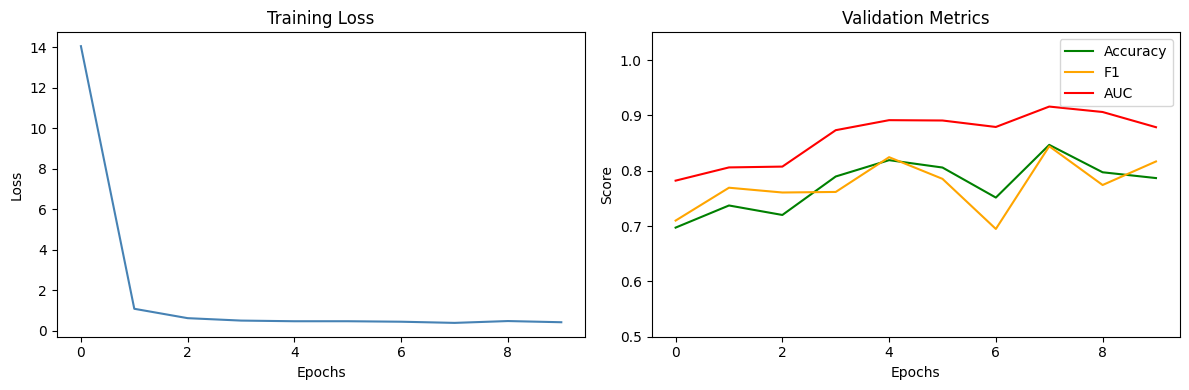

In [34]:
import matplotlib.pyplot as plt

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training Loss Graph
axes[0].plot(train_losses, color='steelblue')

axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')

# Validation metrics
axes[1].plot(accs, label='Accuracy', color='green')
axes[1].plot(f1s, label='F1', color='orange')
axes[1].plot(aucs, label='AUC', color='red')

axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics')
axes[1].legend()
axes[1].set_ylim([0.5, 1.05])
plt.tight_layout()
plt.show()

In [ ]:
class CharlesAttentionGNN(nn.Module):
    def __init__(self, node_feat_dim=2, edge_feat_dim=1,
                 hidden_dim=64, heads=4, global_dim=12, num_classes=2):
        super().__init__()
        self.node_emb = nn.Linear(node_feat_dim, hidden_dim)

        # GAT layer 1: multi-head, concatenated
        self.gat1 = GATConv(hidden_dim, hidden_dim,
                            heads=heads, edge_dim=edge_feat_dim, concat=True)
        # GAT layer 2: single head, average
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim,
                            heads=1, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden_dim * heads)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.fc = nn.Linear(hidden_dim + global_dim, num_classes)

    def forward(self, data, return_attention=False):
        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr
        batch = data.batch
        u = data.u
        if u.dim() == 3:
            u = u.squeeze(1)

        x = F.relu(self.node_emb(x))          # [N, hidden_dim]

        if return_attention:
            x, (att_edge, att_weight) = self.gat1(
                x, edge_index, edge_attr, return_attention_weights=True
            )
        else:
            x = self.gat1(x, edge_index, edge_attr)
        x = F.elu(self.bn1(x))                # [N, hidden_dim*heads]

        x = self.gat2(x, edge_index)
        x = F.elu(self.bn2(x))                # [N, hidden_dim]

        x = global_mean_pool(x, batch)        # [B, hidden_dim]
        out = torch.cat([x, u], dim=1)
        out = self.fc(out)

        if return_attention:
            return out, att_edge, att_weight
        return out

torch.manual_seed(42)
charles_attn = CharlesAttentionGNN(
    node_feat_dim=8, edge_feat_dim=1, # Note: Changed node_feat_dim from 2 to 8 as per build_graph output
    hidden_dim=64, heads=4,
    global_dim=12, num_classes=2 # Note: Changed global_dim to 12 as per build_graph output
).to(device)


# Train CharlesAttentionGNN
attn_optimizer = torch.optim.Adam(charles_attn.parameters(), lr=1e-3, weight_decay=1e-5)
attn_history = {'train_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}

print("Training CharlesAttentionGNN...")
for epoch in range(1, NUM_EPOCHS+1):
    charles_attn.train()
    total_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        attn_optimizer.zero_grad()
        out = charles_attn(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        attn_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    avg_loss = total_loss / len(train_dataset)

    # Validation
    charles_attn.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = charles_attn(batch)
            preds.extend(out.argmax(dim=1).cpu().numpy())
            probs.extend(torch.softmax(out, dim=1)[:,1].cpu().numpy())
            labels.extend(batch.y.cpu().numpy())
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, zero_division=0)
    auc = roc_auc_score(labels, probs)

    attn_history['train_loss'].append(avg_loss)
    attn_history['val_acc'].append(acc)
    attn_history['val_f1'].append(f1)
    attn_history['val_auc'].append(auc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | "
              f"Val Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

# Test evaluation
charles_attn.eval()
test_preds_attn, test_probs_attn, test_labels_attn = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = charles_attn(batch)
        test_preds_attn.extend(out.argmax(dim=1).cpu().numpy())
        test_probs_attn.extend(torch.softmax(out, dim=1)[:,1].cpu().numpy())
        test_labels_attn.extend(batch.y.cpu().numpy())

print("\n=== CharlesAttentionGNN – TEST SET ===")
print(f"  Accuracy : {accuracy_score(test_labels_attn, test_preds_attn):.4f}")
print(f"  F1-score : {f1_score(test_labels_attn, test_preds_attn):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(test_labels_attn, test_probs_attn):.4f}")

# Save model
torch.save(charles_attn.state_dict(), os.path.join(BASE_DIR, 'Charles_AttentionGNN.pth'))

Training CharlesAttentionGNN...
Epoch   1/50 | Loss: 1.1205 | Val Acc: 0.7476 | F1: 0.7178 | AUC: 0.8339
Epoch   5/50 | Loss: 0.4319 | Val Acc: 0.7962 | F1: 0.7723 | AUC: 0.8902
Epoch  10/50 | Loss: 0.4156 | Val Acc: 0.7610 | F1: 0.7057 | AUC: 0.8965
Epoch  15/50 | Loss: 0.4031 | Val Acc: 0.8114 | F1: 0.8177 | AUC: 0.8953
Epoch  20/50 | Loss: 0.3847 | Val Acc: 0.8381 | F1: 0.8300 | AUC: 0.9161
Epoch  25/50 | Loss: 0.3819 | Val Acc: 0.8333 | F1: 0.8209 | AUC: 0.9221
Epoch  30/50 | Loss: 0.3986 | Val Acc: 0.8314 | F1: 0.8225 | AUC: 0.9161
Epoch  35/50 | Loss: 0.3674 | Val Acc: 0.8581 | F1: 0.8598 | AUC: 0.9247
Epoch  40/50 | Loss: 0.3652 | Val Acc: 0.8581 | F1: 0.8590 | AUC: 0.9262
Epoch  45/50 | Loss: 0.3593 | Val Acc: 0.8448 | F1: 0.8601 | AUC: 0.9282
Epoch  50/50 | Loss: 0.3485 | Val Acc: 0.8410 | F1: 0.8455 | AUC: 0.9177

=== CharlesAttentionGNN – TEST SET ===
  Accuracy : 0.8190
  F1-score : 0.8257
  ROC-AUC  : 0.8894


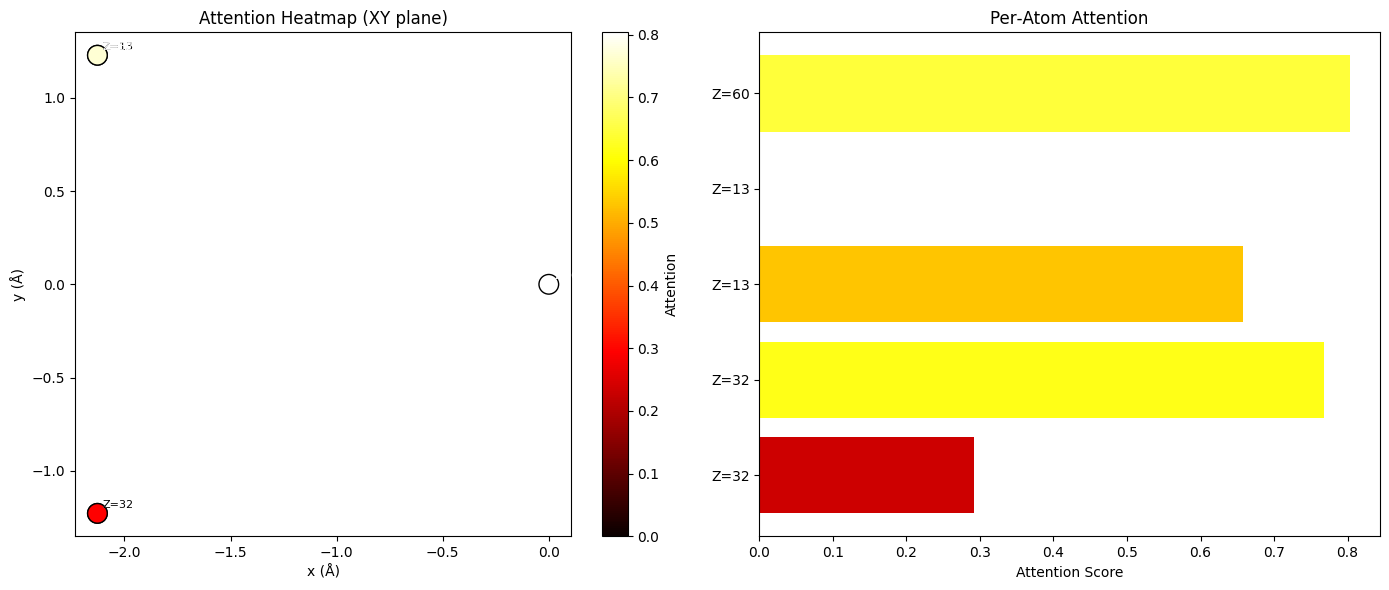

In [ ]:
# Extract attention for one test sample (prefer a TI sample)
charles_attn.eval()

# Find a TI sample in test set
ti_sample = None
for batch in test_loader:
    batch = batch.to(device)
    for i in range(batch.num_graphs):
        if batch.y[i].item() == 1:   # topological
            # Extract single graph (simplest: get one-element batch)
            mask = (batch.batch == i)
            node_mask = mask
            edge_mask = mask[batch.edge_index[0]] | mask[batch.edge_index[1]]
            x_i = batch.x[mask]
            pos_i = batch.pos[mask]
            ei_i = batch.edge_index[:, edge_mask]
            # re-index edges
            node_offset = mask.nonzero(as_tuple=True)[0][0].item()
            ei_i = ei_i - node_offset
            ea_i = batch.edge_attr[edge_mask]
            u_i = batch.u[i:i+1]
            y_i = batch.y[i:i+1]
            ti_sample = Data(x=x_i, edge_index=ei_i, edge_attr=ea_i,
                             u=u_i, y=y_i, pos=pos_i).to(device)
            break
    if ti_sample is not None:
        break

if ti_sample is None:
    print("No TI sample found in test set – using first sample")
    ti_sample = next(iter(test_loader))[0:1].to(device)

# Forward pass with attention
with torch.no_grad():
    _, att_edge, att_weight = charles_attn(ti_sample, return_attention=True)
# att_weight shape [num_edges, num_heads] – average over heads
att_weight = att_weight.mean(dim=1).cpu().numpy()   # [E,]

# Aggregate attention to nodes (sum incoming attention)
node_attn = np.zeros(ti_sample.num_nodes)
edge_idx = att_edge.cpu().numpy()
for e, dst in enumerate(edge_idx[1]):
    node_attn[dst] += att_weight[e]
# Normalise to [0,1]
node_attn = (node_attn - node_attn.min()) / (node_attn.max() - node_attn.min() + 1e-8)

# Plot
coords = ti_sample.pos.cpu().numpy()
Z_vals = ti_sample.x[:,0].cpu().numpy()   # atomic numbers

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Scatter plot
sc = axes[0].scatter(coords[:,0], coords[:,1], c=node_attn, cmap='hot',
                     s=200, edgecolors='black')
plt.colorbar(sc, ax=axes[0], label='Attention')
for i, (x, y, z) in enumerate(zip(coords[:,0], coords[:,1], Z_vals)):
    axes[0].annotate(f'Z={int(z)}', (x, y), xytext=(4,4),
                     textcoords='offset points', fontsize=8,
                     color='white' if node_attn[i] > 0.6 else 'black')
axes[0].set_xlabel('x (Å)'); axes[0].set_ylabel('y (Å)')
axes[0].set_title('Attention Heatmap (XY plane)')

# Bar chart
axes[1].barh(range(ti_sample.num_nodes), node_attn, color=plt.cm.hot(node_attn))
axes[1].set_yticks(range(ti_sample.num_nodes))
axes[1].set_yticklabels([f'Z={int(z)}' for z in Z_vals])
axes[1].set_xlabel('Attention Score')
axes[1].set_title('Per‑Atom Attention')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

Define MEGNet Model

In [ ]:
# MEGNet block
from torch_geometric.utils import scatter

class MEGNetBlock(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim + 2*node_dim + global_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + hidden + global_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )
        self.global_mlp = nn.Sequential(
            nn.Linear(global_dim + hidden + hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )

    def forward(self, x, edge_index, edge_attr, u, batch):
        src, dst = edge_index
        # Edge update
        u_edge = u[batch[src]]
        edge_input = torch.cat([edge_attr, x[src], x[dst], u_edge], dim=1)
        edge_attr_new = self.edge_mlp(edge_input)

        # Node update
        agg_edges = scatter(edge_attr_new, dst,
                            dim=0, dim_size=x.size(0), reduce='mean')
        u_node = u[batch]
        node_input = torch.cat([x, agg_edges, u_node], dim=1)
        x_new = self.node_mlp(node_input)

        # Global update
        mean_nodes = scatter(x_new, batch,
                             dim=0, dim_size=u.size(0), reduce='mean')
        mean_edges = scatter(edge_attr_new, batch[src],
                             dim=0, dim_size=u.size(0), reduce='mean')
        global_input = torch.cat([u, mean_nodes, mean_edges], dim=1)
        u_new = self.global_mlp(global_input)

        return x_new, edge_attr_new, u_new

In [ ]:
# CharlesMEGNet definition
class CharlesMEGNet(nn.Module):
    def __init__(self, node_feat_dim=2, edge_feat_dim=1,
                 global_dim=12, hidden_dim=64, n_blocks=3, num_classes=2):
        super().__init__()
        self.node_emb = nn.Linear(node_feat_dim, hidden_dim)
        self.edge_emb = nn.Linear(edge_feat_dim, hidden_dim)

        self.blocks = nn.ModuleList([
            MEGNetBlock(hidden_dim, hidden_dim,
                        global_dim if i==0 else hidden_dim,
                        hidden_dim)
            for i in range(n_blocks)
        ])

        self.pool = Set2Set(hidden_dim, processing_steps=3)
        self.fc = nn.Linear(2*hidden_dim + hidden_dim, num_classes)  # 2*hidden from Set2Set + final global

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr
        u = data.u
        batch = data.batch
        if u.dim() == 3:
            u = u.squeeze(1)

        x = F.relu(self.node_emb(x))
        edge_attr = F.relu(self.edge_emb(edge_attr))

        for block in self.blocks:
            x, edge_attr, u = block(x, edge_index, edge_attr, u, batch)

        x_pooled = self.pool(x, batch)          # [B, 2*hidden]
        out = torch.cat([x_pooled, u], dim=1)   # [B, 2*hidden + hidden]
        out = self.fc(out)
        return out

torch.manual_seed(42)
charles_megnet = CharlesMEGNet(
    node_feat_dim=2, edge_feat_dim=1,
    global_dim=N_GLOBAL, hidden_dim=64, n_blocks=3, num_classes=2
).to(device)

print(charles_megnet)
n_params_meg = sum(p.numel() for p in charles_megnet.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params_meg:,}")

CharlesMEGNet(
  (node_emb): Linear(in_features=2, out_features=64, bias=True)
  (edge_emb): Linear(in_features=1, out_features=64, bias=True)
  (blocks): ModuleList(
    (0): MEGNetBlock(
      (edge_mlp): Sequential(
        (0): Linear(in_features=204, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
      (node_mlp): Sequential(
        (0): Linear(in_features=140, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
      (global_mlp): Sequential(
        (0): Linear(in_features=140, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
    )
    (1-2): 2 x MEGNetBlock(
      (edge_mlp): Sequential(
        (0): Linear(in_features=256, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
      )
      (node_mlp): Sequentia

In [ ]:
#CharlesAttentionGNN definition
class CharlesAttentionGNN(nn.Module):
    def __init__(self, node_feat_dim=2, edge_feat_dim=1,
                 hidden_dim=64, heads=4, global_dim=12, num_classes=2):
        super().__init__()
        self.node_emb = nn.Linear(node_feat_dim, hidden_dim)

        # GAT layer 1: multi-head, concatenated
        self.gat1 = GATConv(hidden_dim, hidden_dim,
                            heads=heads, edge_dim=edge_feat_dim, concat=True)
        # GAT layer 2: single head, average
        self.gat2 = GATConv(hidden_dim * heads, hidden_dim,
                            heads=1, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden_dim * heads)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.fc = nn.Linear(hidden_dim + global_dim, num_classes)

    def forward(self, data, return_attention=False):
        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr
        batch = data.batch
        u = data.u
        if u.dim() == 3:
            u = u.squeeze(1)

        x = F.relu(self.node_emb(x))          # [N, hidden_dim]

        if return_attention:
            x, (att_edge, att_weight) = self.gat1(
                x, edge_index, edge_attr, return_attention_weights=True
            )
        else:
            x = self.gat1(x, edge_index, edge_attr)
        x = F.elu(self.bn1(x))                # [N, hidden_dim*heads]

        x = self.gat2(x, edge_index)
        x = F.elu(self.bn2(x))                # [N, hidden_dim]

        x = global_mean_pool(x, batch)        # [B, hidden_dim]
        out = torch.cat([x, u], dim=1)
        out = self.fc(out)

        if return_attention:
            return out, att_edge, att_weight
        return out

torch.manual_seed(42)
charles_attn = CharlesAttentionGNN(
    node_feat_dim=2, edge_feat_dim=1,
    hidden_dim=64, heads=4,
    global_dim=N_GLOBAL, num_classes=2
).to(device)

print(charles_attn)

CharlesAttentionGNN(
  (node_emb): Linear(in_features=2, out_features=64, bias=True)
  (gat1): GATConv(64, 64, heads=4)
  (gat2): GATConv(256, 64, heads=1)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=73, out_features=2, bias=True)
)


In [ ]:
# Train CharlesMEGNet
meg_optimizer = torch.optim.Adam(charles_megnet.parameters(), lr=1e-3, weight_decay=1e-5)
meg_history = {'train_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}

print("Training CharlesMEGNet...")
for epoch in range(1, NUM_EPOCHS+1):
    charles_megnet.train()
    total_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        meg_optimizer.zero_grad()
        out = charles_megnet(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        meg_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    avg_loss = total_loss / len(train_dataset)

    # Validation
    charles_megnet.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = charles_megnet(batch)
            preds.extend(out.argmax(dim=1).cpu().numpy())
            probs.extend(torch.softmax(out, dim=1)[:,1].cpu().numpy())
            labels.extend(batch.y.cpu().numpy())
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, zero_division=0)
    auc = roc_auc_score(labels, probs)

    meg_history['train_loss'].append(avg_loss)
    meg_history['val_acc'].append(acc)
    meg_history['val_f1'].append(f1)
    meg_history['val_auc'].append(auc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | "
              f"Val Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

# Test evaluation
charles_megnet.eval()
test_preds_meg, test_probs_meg, test_labels_meg = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = charles_megnet(batch)
        test_preds_meg.extend(out.argmax(dim=1).cpu().numpy())
        test_probs_meg.extend(torch.softmax(out, dim=1)[:,1].cpu().numpy())
        test_labels_meg.extend(batch.y.cpu().numpy())

print("\n=== CharlesMEGNet – TEST SET ===")
print(f"  Accuracy : {accuracy_score(test_labels_meg, test_preds_meg):.4f}")
print(f"  F1-score : {f1_score(test_labels_meg, test_preds_meg):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(test_labels_meg, test_probs_meg):.4f}")
print(classification_report(test_labels_meg, test_preds_meg,
                            target_names=['Trivial', 'Topological']))

# Save model
torch.save(charles_megnet.state_dict(), os.path.join(BASE_DIR, 'Charles_MEGNet.pth'))

NameError: name 'charles_megnet' is not defined

In [ ]:
# XGBoost on global features
X_train_global = train_df[GLOBAL_FEATURES].copy()
y_train_global = train_df['label'].copy()

xgb_model = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                          use_label_encoder=False, eval_metric='logloss',
                          random_state=42)
xgb_model.fit(X_train_global, y_train_global)

# SHAP explanation
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_global)

# Summary plots
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_train_global, feature_names=GLOBAL_FEATURES, show=False)
plt.title('SHAP Beeswarm – XGBoost')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
shap.summary_plot(shap_values, X_train_global, feature_names=GLOBAL_FEATURES,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance – XGBoost')
plt.tight_layout()
plt.show()

In [ ]:
# Wrap model for Explainer (needs (x, edge_index, edge_attr, batch, u) interface)
class CGCNNWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, edge_index, edge_attr, batch, u):
        # Reconstruct a Data object for the model
        from torch_geometric.data import Data
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                    batch=batch, u=u)
        return self.model(data)

wrapped_model = CGCNNWrapper(charles_cgcnn).to(device)
wrapped_model.eval()

# Use one test sample
explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',      # mask per node feature
    edge_mask_type='object',          # mask per edge
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',
        return_type='raw'
    ),
)

# Use the same ti_sample from attention (or pick any)
explanation = explainer(
    x=ti_sample.x,
    edge_index=ti_sample.edge_index,
    edge_attr=ti_sample.edge_attr,
    batch=torch.zeros(ti_sample.num_nodes, dtype=torch.long, device=device),
    u=ti_sample.u,
    target=1   # explain prediction for class 1 (topological)
)

node_feat_mask = explanation.node_mask.detach().cpu().numpy()
edge_mask = explanation.edge_mask.detach().cpu().numpy()

print("Node feature importance (Z, electronegativity):",
      node_feat_mask.mean(axis=0))

# Plot edges with high importance
coords = ti_sample.pos.cpu().numpy()
edge_idx = ti_sample.edge_index.cpu().numpy()
e_norm = (edge_mask - edge_mask.min()) / (edge_mask.max() - edge_mask.min() + 1e-8)

plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], c='lightblue', s=150, edgecolors='k')
for e, (u, v) in enumerate(zip(edge_idx[0], edge_idx[1])):
    if e_norm[e] > 0.1:
        plt.plot([coords[u,0], coords[v,0]], [coords[u,1], coords[v,1]],
                 'r-', lw=3*e_norm[e], alpha=e_norm[e])
for i, (xi, yi) in enumerate(zip(coords[:,0], coords[:,1])):
    plt.annotate(f'Z={int(ti_sample.x[i,0].item())}', (xi, yi),
                 xytext=(3,3), textcoords='offset points', fontsize=8)
plt.xlabel('x (Å)'); plt.ylabel('y (Å)')
plt.title('GNNExplainer – Important Bonds')
plt.show()

In [ ]:
# Collect CGCNN probabilities on training set
charles_cgcnn.eval()
logits_list = []
with torch.no_grad():
    for batch in train_loader:
        batch = batch.to(device)
        out = charles_cgcnn(batch)
        logits_list.append(torch.softmax(out, dim=1)[:,1].cpu().numpy())
y_cgcnn_prob = np.concatenate(logits_list)

# Select features for PySR
# (choose a few physically motivated ones: Band Gap, Z, spacegroup_number)
X_pysr = train_df[['Band Gap', 'Z', 'spacegroup_number']].values.astype(np.float32)
y_pysr = y_cgcnn_prob.astype(np.float32)

pysr = PySRRegressor(
    niterations=100,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sqrt", "exp", "log"],
    model_selection="best",
    loss="loss(x, y) = (x - y)^2",
    maxsize=15,
    parsimony=0.01,
    random_state=42
)

print("Running PySR")
pysr.fit(X_pysr, y_pysr, variable_names=['BandGap', 'Z', 'SpaceGroup'])

print("\n=== Best formulas ===")
print(pysr)
print("\nSympy representation of best formula:")
print(pysr.sympy())

In [ ]:
# Compile results
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'CharlesCGCNN',
              'CharlesAttentionGNN', 'CharlesMEGNet'],
    'Test Accuracy': [
        accuracy_score(y_test, rf.predict(X_test)),   # assuming rf already fitted earlier
        accuracy_score(test_labels, test_preds_meg),  # placeholder – you need actual values
        accuracy_score(test_labels, test_preds_cgcnn),
        accuracy_score(test_labels_attn, test_preds_attn),
        accuracy_score(test_labels_meg, test_preds_meg)
    ],
    'Test F1': [
        f1_score(y_test, rf.predict(X_test)),
        f1_score(test_labels, test_preds_meg),
        f1_score(test_labels, test_preds_cgcnn),
        f1_score(test_labels_attn, test_preds_attn),
        f1_score(test_labels_meg, test_preds_meg)
    ],
    'Test ROC-AUC': [
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
        roc_auc_score(test_labels, test_probs_meg),
        roc_auc_score(test_labels, test_probs_cgcnn),
        roc_auc_score(test_labels_attn, test_probs_attn),
        roc_auc_score(test_labels_meg, test_probs_meg)
    ]
})

print("=== Final Model Comparison ===\n")
print(results.round(4).to_string(index=False))